# DS605 Lab 6 (Notebook 2 of 2): Text Vectorization and Spam Classification

**Dataset:** Email Spam Classification Dataset, 5,172 emails (Kaggle)
**Covers:** Part B (CountVectorizer text representation) and the text half of Part C (representation improvement)
**Constraint:** No deep learning. Scikit-learn vectorizers and traditional classifiers only.

**Workflow**

```
Raw email text -> Cleaning -> Vectorization -> Train-test split -> ML model -> Evaluation -> Representation improvement
```

**Expected input:** `data/emails.csv`. Two formats are supported automatically:

1. **Raw text:** a text column (for example `text`) and a label column (for example `label` or `label_num`).
2. **Word counts:** the common Kaggle format with one numeric column per vocabulary word and a `Prediction` label column. Each email is rebuilt as a bag-of-words document by repeating each word as often as it was counted, and CountVectorizer is then applied to these documents. Word order is not available in this format, so bigrams are disabled and the vocabulary cap is set to 1,500 words (the original file has 3,000).

The detected format is printed in section B1. Outputs are written to `results/`.

**Companion notebook:** `202618052_Lab_6_Image_Feature_Extraction_and_Classification.ipynb` (Part A and the image half of Part C).

## Concept and intuition

### Why vectorization is necessary
Machine-learning models need numeric input, but an email is a variable-length string. Vectorization maps each email to a fixed-length numeric vector whose length is the vocabulary size.

### Bag-of-words: CountVectorizer
Each entry of the vector is the number of times a vocabulary word occurs in the email. Word order is ignored. The vectors are extremely sparse (most words do not occur in a given email), so scikit-learn stores them as sparse matrices.

### Basic cleaning and why each step is used
Lowercasing merges "Free" and "free". Removing HTML tags, URLs and e-mail addresses removes markup and identifiers that add noise. Keeping alphabetic characters only removes digits and symbols. **Duplicate emails are removed** because identical messages in both the training and test sets would inflate the measured performance (data leakage).

### Avoiding leakage in vectorization
The vectorizer is fitted on the training text only and then applied to the test text. If it were fitted on all the data, the vocabulary would carry information about the test set.

### Why these classifiers
* **Multinomial Naive Bayes:** the classical spam baseline, very fast, designed for word counts.
* **Logistic Regression and Linear SVM:** strong linear models for high-dimensional sparse data, where classes are often close to linearly separable.

### Metrics
For spam filtering, **precision** matters because a false positive is a legitimate email lost, and **recall** matters because a false negative is spam reaching the inbox. F1 balances the two. Vectorization time, training time and prediction time are reported separately so the computational cost of each representation is visible.

## 0. Setup and configuration

In [1]:
import os
import re
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")

# ---- Paths (edit these, or set environment variables) ----
TEXT_CSV = Path(os.environ.get("TEXT_CSV", "data/emails.csv"))
OUT_DIR = Path(os.environ.get("OUT_DIR", "results"))

# ---- Experiment settings ----
TEST_SIZE = 0.20
RANDOM_STATE = 42

OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / "figures").mkdir(exist_ok=True)


def save_fig(fig, name):
    fig.tight_layout()
    fig.savefig(OUT_DIR / "figures" / name, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def metrics_row(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


def timed_fit_predict(model, X_tr, y_tr, X_te):
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    train_time = time.perf_counter() - t0
    t0 = time.perf_counter()
    pred = model.predict(X_te)
    predict_time = time.perf_counter() - t0
    return pred, train_time, predict_time


def plot_confusion_matrices(items, class_names, filename, ncols=3):
    """items: list of (title, 2x2 confusion matrix)."""
    nrows = int(np.ceil(len(items) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.8 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (title, cm) in zip(axes, items):
        ax.imshow(cm, cmap="Blues")
        ax.set_title(title, fontsize=9)
        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_xticklabels(class_names); ax.set_yticklabels(class_names)
        ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
        for i in range(2):
            for j in range(2):
                ax.text(j, i, cm[i, j], ha="center", va="center",
                        color="white" if cm[i, j] > cm.max() / 2 else "black")
    for ax in axes[len(items):]:
        ax.axis("off")
    save_fig(fig, filename)

# Part B: Text vectorization and spam classification

## B1. Load data and inspect the class distribution

File shape: (5172, 3002)
Word-count format detected: 2999 vocabulary columns. Emails were rebuilt as bag-of-words documents.
Input mode: word_counts | improved n-gram range: (1, 1) | improved max_features: 1500

Emails loaded: 5172
label
ham (not spam)    3672
spam              1500
Name: count, dtype: int64
label
ham (not spam)    0.71
spam              0.29
Name: proportion, dtype: float64


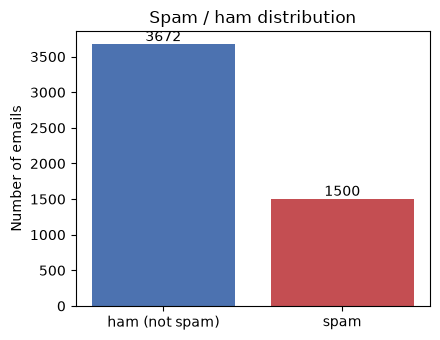

In [2]:
if not TEXT_CSV.exists():
    raise FileNotFoundError(f"Email file not found: {TEXT_CSV.resolve()}. Run the notebook from the folder that contains 'data/'.")

df_raw = pd.read_csv(TEXT_CSV, encoding_errors="replace")
print("File shape:", df_raw.shape)
lower = {c.lower(): c for c in df_raw.columns}

text_col = next((lower[k] for k in ["text", "message", "email", "body", "v2", "content", "email_text"]
                 if k in lower and not pd.api.types.is_numeric_dtype(df_raw[lower[k]])), None)
label_col = next((lower[k] for k in ["label_num", "label", "prediction", "category", "class", "spam", "v1"] if k in lower), None)
if label_col is None:
    raise ValueError(f"No label column found. Columns are: {list(df_raw.columns)[:10]} ...")

if text_col is not None:
    # Case 1: the file contains the raw email text
    INPUT_MODE = "raw_text"
    docs = df_raw[text_col].astype(str)
else:
    # Case 2: the file contains word-count columns (one column per vocabulary word).
    # Each email is rebuilt as a bag-of-words document by repeating each word as many times as
    # it was counted. CountVectorizer is then applied to these documents. Word order
    # is not available in this file, so n-grams cannot be used.
    INPUT_MODE = "word_counts"
    id_cols = [c for c in df_raw.columns if c.lower().startswith("email no") or c.lower() in {"id", "unnamed: 0"}]
    word_cols = [c for c in df_raw.columns
                 if c != label_col and c not in id_cols and pd.api.types.is_numeric_dtype(df_raw[c])]
    counts = df_raw[word_cols].fillna(0).clip(lower=0).astype(int).values
    vocab_arr = np.array(word_cols, dtype=object)
    docs = pd.Series([" ".join(np.repeat(vocab_arr, row)) for row in counts])
    print(f"Word-count format detected: {len(word_cols)} vocabulary columns. "
          f"Emails were rebuilt as bag-of-words documents.")

NGRAM_RANGE = (1, 2) if INPUT_MODE == "raw_text" else (1, 1)
MAX_FEATURES = 5000 if INPUT_MODE == "raw_text" else 1500
print(f"Input mode: {INPUT_MODE} | improved n-gram range: {NGRAM_RANGE} | improved max_features: {MAX_FEATURES}")


def to_binary(v):
    if isinstance(v, (int, np.integer, float, np.floating)):
        return int(v)
    s = str(v).strip().lower()
    return 0 if s in {"ham", "not spam", "non-spam", "nonspam", "legitimate", "0"} else 1


df = pd.DataFrame({"raw_text": docs.values, "raw_label": df_raw[label_col].values}).dropna()
df["label"] = df["raw_label"].map(to_binary)
print(f"\nEmails loaded: {len(df)}")
dist = df["label"].value_counts().rename({0: "ham (not spam)", 1: "spam"})
print(dist, "\n", (dist / len(df)).round(3).rename("proportion"), sep="")

fig, ax = plt.subplots(figsize=(4.5, 3.5))
ax.bar(dist.index, dist.values, color=["#4C72B0", "#C44E52"])
ax.set_ylabel("Number of emails"); ax.set_title("Spam / ham distribution")
for i, v in enumerate(dist.values):
    ax.text(i, v, str(v), ha="center", va="bottom")
save_fig(fig, "text_class_distribution.png")

## B2. Basic text cleaning

Steps: lowercase, strip the leading "Subject:" tag, remove HTML tags, URLs and e-mail
addresses, keep alphabetic characters only, collapse whitespace, then drop empty and
duplicate messages. Duplicates are removed because identical emails falling in both the
train and test sets would inflate the measured performance (data leakage).

In [3]:
def clean_text(t):
    t = str(t).lower()
    t = re.sub(r"^\s*subject:\s*", "", t)
    t = re.sub(r"<[^>]+>", " ", t)
    t = re.sub(r"http\S+|www\.\S+", " ", t)
    t = re.sub(r"\S+@\S+", " ", t)
    t = re.sub(r"[^a-z\s]", " ", t)
    return re.sub(r"\s+", " ", t).strip()


df["clean_text"] = df["raw_text"].map(clean_text)
n0 = len(df)
df = df[df["clean_text"].str.len() > 0].drop_duplicates(subset="clean_text").reset_index(drop=True)
print(f"Removed {n0 - len(df)} empty/duplicate emails; {len(df)} remain.")
if df.empty or df["label"].nunique() < 2:
    raise ValueError("Cleaning left fewer than two usable classes. Check the text and label columns in the input CSV.")
print("\nExample (raw -> cleaned):")
print(df["raw_text"].iloc[0][:200].replace("\n", " "), "\n->", df["clean_text"].iloc[0][:200])

X_txt_tr, X_txt_te, y_txt_tr, y_txt_te = train_test_split(
    df["clean_text"], df["label"].values, test_size=TEST_SIZE,
    stratify=df["label"].values, random_state=RANDOM_STATE)
CLASS_NAMES_TXT = ["ham", "spam"]

Removed 541 empty/duplicate emails; 4631 remain.

Example (raw -> cleaned):
ect a a is i i s s s as re re e e e e t t t t j m m b p c c c r r r r f h u u tu st ic far chris hr rm tr pictures pi ma picture ct ct christmas ur tm 
-> ect a a is i i s s s as re re e e e e t t t t j m m b p c c c r r r r f h u u tu st ic far chris hr rm tr pictures pi ma picture ct ct christmas ur tm


## B3. CountVectorizer baseline

The vectorizer is fitted on the training text only, then applied to the test text.
This prevents vocabulary statistics from leaking from the test set. The baseline uses the
default CountVectorizer: full vocabulary, unigrams, no stop-word removal.

In [4]:
def text_models():
    return {
        "Multinomial NB": MultinomialNB(),
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "Linear SVM": LinearSVC(random_state=RANDOM_STATE),
    }


def run_text_experiment(config, vec_name, vec):
    t0 = time.perf_counter()
    Xtr = vec.fit_transform(X_txt_tr)
    Xte = vec.transform(X_txt_te)
    vec_time = time.perf_counter() - t0
    rows, cms = [], {}
    for name, model in text_models().items():
        pred, tt, tp = timed_fit_predict(model, Xtr, y_txt_tr, Xte)
        rows.append({"config": config, "vectorizer": vec_name, "model": name,
                     "n_features": Xtr.shape[1],
                     "sparsity": 1 - Xtr.nnz / (Xtr.shape[0] * Xtr.shape[1]),
                     **metrics_row(y_txt_te, pred),
                     "vectorize_time_s": vec_time, "train_time_s": tt, "predict_time_s": tp})
        cms[(config, vec_name, name)] = confusion_matrix(y_txt_te, pred)
    return rows, cms


text_rows, text_cms = [], {}
for vec_name, vec in [("CountVectorizer", CountVectorizer())]:
    r, c = run_text_experiment("Baseline", vec_name, vec)
    text_rows += r; text_cms.update(c)

res_text_base = pd.DataFrame(text_rows)
print(res_text_base.round(4).to_string(index=False))

  config      vectorizer               model  n_features  sparsity  accuracy  precision  recall     f1  vectorize_time_s  train_time_s  predict_time_s
Baseline CountVectorizer      Multinomial NB        2973    0.9485    0.9450     0.8825  0.9521 0.9160            2.0192        0.0040          0.0016
Baseline CountVectorizer Logistic Regression        2973    0.9485    0.9676     0.9338  0.9658 0.9495            2.0192        0.4827          0.0013
Baseline CountVectorizer          Linear SVM        2973    0.9485    0.9676     0.9367  0.9623 0.9493            2.0192        2.2045          0.0008


## B4. Reading the baseline results

* Which classifier gave the best precision, recall and F1 on the baseline CountVectorizer, and is the gap meaningful given the size of the test set?
* How many features does the baseline generate (the full vocabulary), and how sparse is the matrix?
* Compare vectorization time, training time and prediction time.

# Part C (text): Improve the representation

## C1. Stop-word removal, bigrams and vocabulary limiting

| Change | Justification |
|---|---|
| Stop-word removal | Common words such as "the" and "of" appear in both classes and add dimensions without discriminating information. |
| Unigrams + bigrams (raw-text files only) | Phrases such as "click here" or "free offer" are more spam-specific than either word alone. With the word-count file, word order is unavailable and only unigrams are used. |
| `min_df=2` | Discards rare tokens (typos, names, identifiers) that seldom generalise and dominate the dimensionality. |
| `max_features` (5000 for raw text, 1500 for the word-count file) | Bounds memory and computation. Bigrams enlarge the vocabulary, so the cap is what keeps it controlled. |

In [5]:
# Improvement is applied in two steps so the effect of each change can be seen:
#   1. Stop-word removal only
#   2. Stop words + n-grams + minimum document frequency + vocabulary cap (final improved setup)
improved_vecs = [
    ("Stop words only", "CountVectorizer", CountVectorizer(stop_words="english")),
    ("Improved", "CountVectorizer",
     CountVectorizer(stop_words="english", ngram_range=NGRAM_RANGE, min_df=2, max_features=MAX_FEATURES)),
]
text_rows_imp = []
for config, vec_name, vec in improved_vecs:
    r, c = run_text_experiment(config, vec_name, vec)
    text_rows_imp += r; text_cms.update(c)

res_text = pd.concat([res_text_base, pd.DataFrame(text_rows_imp)], ignore_index=True)
res_text.to_csv(OUT_DIR / "text_results.csv", index=False)
print(res_text.round(4).to_string(index=False))

         config      vectorizer               model  n_features  sparsity  accuracy  precision  recall     f1  vectorize_time_s  train_time_s  predict_time_s
       Baseline CountVectorizer      Multinomial NB        2973    0.9485    0.9450     0.8825  0.9521 0.9160            2.0192        0.0040          0.0016
       Baseline CountVectorizer Logistic Regression        2973    0.9485    0.9676     0.9338  0.9658 0.9495            2.0192        0.4827          0.0013
       Baseline CountVectorizer          Linear SVM        2973    0.9485    0.9676     0.9367  0.9623 0.9493            2.0192        2.2045          0.0008
Stop words only CountVectorizer      Multinomial NB        2737    0.9595    0.9385     0.8707  0.9452 0.9064            2.1173        0.0032          0.0011
Stop words only CountVectorizer Logistic Regression        2737    0.9595    0.9687     0.9398  0.9623 0.9509            2.1173        0.2802          0.0008
Stop words only CountVectorizer          Linear SVM 

## C2. Baseline vs improved: summary and trade-off

Best text model per (configuration, vectorizer):
         config      vectorizer               model  n_features  accuracy  precision  recall     f1  vectorize_time_s  train_time_s  predict_time_s
Stop words only CountVectorizer Logistic Regression        2737    0.9687     0.9398  0.9623 0.9509            2.1173        0.2802          0.0008
       Baseline CountVectorizer Logistic Regression        2973    0.9676     0.9338  0.9658 0.9495            2.0192        0.4827          0.0013
       Improved CountVectorizer Logistic Regression        1500    0.9676     0.9426  0.9555 0.9490            1.9727        0.2259          0.0014


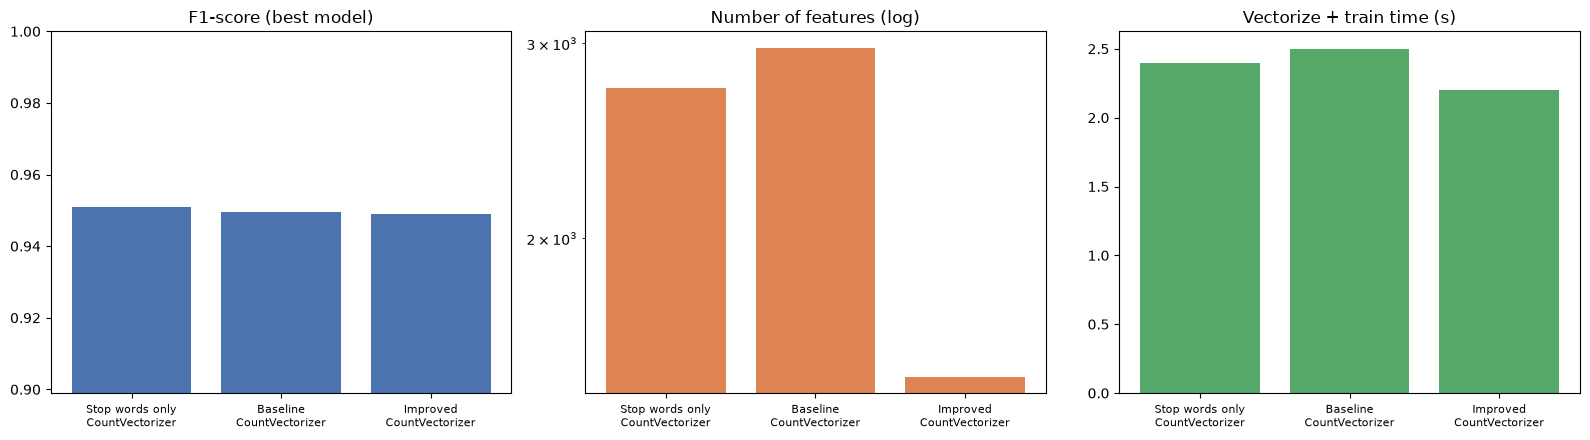

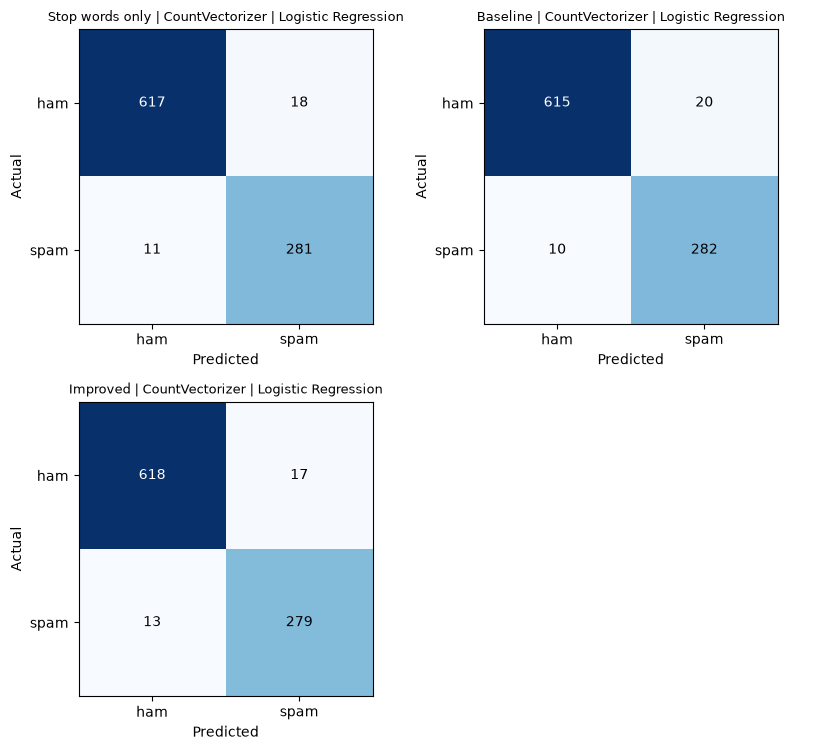


Saved files:
  results\figures\text_class_distribution.png
  results\figures\text_confusion_matrices.png
  results\figures\text_representation_comparison.png
  results\text_results.csv


In [6]:
def best_per_group(df_, group_cols):
    return (df_.sort_values(["f1", "predict_time_s"], ascending=[False, True])
               .groupby(group_cols, sort=False).head(1))


best_text = best_per_group(res_text, ["config", "vectorizer"])
print("Best text model per (configuration, vectorizer):")
print(best_text[["config", "vectorizer", "model", "n_features", "accuracy", "precision", "recall", "f1",
                 "vectorize_time_s", "train_time_s", "predict_time_s"]].round(4).to_string(index=False))

labels = [f"{r.config}\n{r.vectorizer}" for r in best_text.itertuples()]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].bar(labels, best_text["f1"], color="#4C72B0"); axes[0].set_title("F1-score (best model)")
axes[0].set_ylim(max(0, best_text["f1"].min() - 0.05), 1.0)
axes[1].bar(labels, best_text["n_features"], color="#DD8452"); axes[1].set_yscale("log"); axes[1].set_title("Number of features (log)")
axes[2].bar(labels, best_text["vectorize_time_s"] + best_text["train_time_s"], color="#55A868"); axes[2].set_title("Vectorize + train time (s)")
for ax in axes:
    ax.tick_params(axis="x", labelsize=8)
save_fig(fig, "text_representation_comparison.png")

plot_confusion_matrices(
    [(f"{r.config} | {r.vectorizer} | {r.model}", text_cms[(r.config, r.vectorizer, r.model)])
     for r in best_text.itertuples()], CLASS_NAMES_TXT, "text_confusion_matrices.png", ncols=2)

print("\nSaved files:")
for f in sorted(OUT_DIR.rglob("*")):
    if f.is_file():
        print(" ", f)

## Observations and conclusions (complete after running on the real dataset)

Cite specific numbers from the tables and figures above.

1. **Class balance.** What is the spam/ham ratio, and does it make accuracy alone misleading?
2. **Baseline vs improved CountVectorizer.** Compare the baseline, the stop-words-only step and the final improved setup on precision, recall and F1 for each classifier. Was the effect consistent across models?
3. **Dimensionality.** How many features did each configuration generate, and how sparse were the matrices?
4. **Effect of the improvements.** How did stop-word removal, bigrams, `min_df` and `max_features` change accuracy, feature count, vectorization time and training time?
5. **Trade-off.** Did limiting the vocabulary reduce computation without harming performance? Did bigrams add value beyond the cost of a larger vocabulary?
6. **Error analysis.** From the confusion matrices, are false positives (legitimate email marked as spam) or false negatives more frequent, and which is more costly for a spam filter?
7. **Limitations.** Consider duplicate removal, the single train-test split, and the dataset's origin (a dataset from one source may not generalise to other mail).